<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Projects/Projects-2/HousingDataClean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LINEAR REGGRESSION AND HOUSING DATA ANALYSIS

# The business problem.


The **Ames Housing** data set, a structured CSV contains a mixture of nominal (neighborhoods), ordinal (quality ratings), continuous
(sales price, square footage) and discrete (count of rooms) variables.

 Our target is 'SalePrice' = 'y' and features are denoted by 'X.'  SalePrice is a continous number in the data so we selected regression modeling.  The goal - accurately predict the sales price, from features - identifying what features relate to y variable.


Import libraries.  Data collection/sources: The AMES Housing Data and Housing Data Document (SIZE: 2930 observations, 82 variables)

In [ ]:
import pandas as pd
import numpy as np


from scipy import stats
from rich import print




In [ ]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
housing  = pd.read_csv(url)
housing.shape  # total rows = 2637 and total columns = 81

(2637, 81)

Took the Housing document .pdf and created a queryable, color coded data dictionary as pandas DataFrame this will make it easier to encode the ordinal and nominal data if needed. The code was AI GENERATED

In [ ]:
# Housing Data Dictionary — built from the official documentation PDF
data_dict_rows = [
    ('PID', 'Nominal', 'Parcel identification number'),
    ('MS SubClass', 'Nominal', 'Type of dwelling involved in the sale'),
    ('MS Zoning', 'Nominal', 'General zoning classification of the sale'),
    ('Lot Frontage', 'Continuous', 'Linear feet of street connected to property'),
    ('Lot Area', 'Continuous', 'Lot size in square feet'),
    ('Street', 'Nominal', 'Type of road access to property'),
    ('Alley', 'Nominal', 'Type of alley access (NA = No alley access)'),
    ('Lot Shape', 'Ordinal', 'General shape of property'),
    ('Land Contour', 'Nominal', 'Flatness of the property'),
    ('Utilities', 'Ordinal', 'Type of utilities available'),
    ('Lot Config', 'Nominal', 'Lot configuration'),
    ('Land Slope', 'Ordinal', 'Slope of property'),
    ('Neighborhood', 'Nominal', 'Physical locations within Ames city limits'),
    ('Condition 1', 'Nominal', 'Proximity to various conditions'),
    ('Condition 2', 'Nominal', 'Proximity to various conditions (if more than one)'),
    ('Bldg Type', 'Nominal', 'Type of dwelling'),
    ('House Style', 'Nominal', 'Style of dwelling'),
    ('Overall Qual', 'Ordinal', 'Rates overall material and finish (1-10)'),
    ('Overall Cond', 'Ordinal', 'Rates overall condition of the house (1-10)'),
    ('Year Built', 'Discrete', 'Original construction date'),
    ('Year Remod/Add', 'Discrete', 'Remodel date (= construction date if no remodel)'),
    ('Roof Style', 'Nominal', 'Type of roof'),
    ('Roof Matl', 'Nominal', 'Roof material'),
    ('Exterior 1st', 'Nominal', 'Exterior covering on house'),
    ('Exterior 2nd', 'Nominal', 'Exterior covering (if more than one material)'),
    ('Mas Vnr Type', 'Nominal', 'Masonry veneer type'),
    ('Mas Vnr Area', 'Continuous', 'Masonry veneer area in square feet'),
    ('Exter Qual', 'Ordinal', 'Quality of exterior material'),
    ('Exter Cond', 'Ordinal', 'Present condition of exterior material'),
    ('Foundation', 'Nominal', 'Type of foundation'),
    ('Bsmt Qual', 'Ordinal', 'Height of basement (NA = No Basement)'),
    ('Bsmt Cond', 'Ordinal', 'General condition of basement (NA = No Basement)'),
    ('Bsmt Exposure', 'Ordinal', 'Walkout or garden level walls (NA = No Basement)'),
    ('BsmtFin Type 1', 'Ordinal', 'Rating of basement finished area (NA = No Basement)'),
    ('BsmtFin SF 1', 'Continuous', 'Type 1 finished square feet'),
    ('BsmtFin Type 2', 'Ordinal', 'Rating of basement finished area (multi-types)'),
    ('BsmtFin SF 2', 'Continuous', 'Type 2 finished square feet'),
    ('Bsmt Unf SF', 'Continuous', 'Unfinished square feet of basement area'),
    ('Total Bsmt SF', 'Continuous', 'Total square feet of basement area'),
    ('Heating', 'Nominal', 'Type of heating'),
    ('Heating QC', 'Ordinal', 'Heating quality and condition'),
    ('Central Air', 'Nominal', 'Central air conditioning (Y/N)'),
    ('Electrical', 'Ordinal', 'Electrical system'),
    ('1st Flr SF', 'Continuous', 'First floor square feet'),
    ('2nd Flr SF', 'Continuous', 'Second floor square feet'),
    ('Low Qual Fin SF', 'Continuous', 'Low quality finished square feet (all floors)'),
    ('Gr Liv Area', 'Continuous', 'Above grade (ground) living area square feet'),
    ('Bsmt Full Bath', 'Discrete', 'Basement full bathrooms'),
    ('Bsmt Half Bath', 'Discrete', 'Basement half bathrooms'),
    ('Full Bath', 'Discrete', 'Full bathrooms above grade'),
    ('Half Bath', 'Discrete', 'Half baths above grade'),
    ('Bedroom AbvGr', 'Discrete', 'Bedrooms above grade (not basement)'),
    ('Kitchen AbvGr', 'Discrete', 'Kitchens above grade'),
    ('Kitchen Qual', 'Ordinal', 'Kitchen quality'),
    ('TotRms AbvGrd', 'Discrete', 'Total rooms above grade (not bathrooms)'),
    ('Functional', 'Ordinal', 'Home functionality'),
    ('Fireplaces', 'Discrete', 'Number of fireplaces'),
    ('Fireplace Qu', 'Ordinal', 'Fireplace quality (NA = No Fireplace)'),
    ('Garage Type', 'Nominal', 'Garage location (NA = No Garage)'),
    ('Garage Yr Blt', 'Discrete', 'Year garage was built'),
    ('Garage Finish', 'Ordinal', 'Interior finish of garage (NA = No Garage)'),
    ('Garage Cars', 'Discrete', 'Size of garage in car capacity'),
    ('Garage Area', 'Continuous', 'Size of garage in square feet'),
    ('Garage Qual', 'Ordinal', 'Garage quality (NA = No Garage)'),
    ('Garage Cond', 'Ordinal', 'Garage condition (NA = No Garage)'),
    ('Paved Drive', 'Ordinal', 'Paved driveway'),
    ('Wood Deck SF', 'Continuous', 'Wood deck area in square feet'),
    ('Open Porch SF', 'Continuous', 'Open porch area in square feet'),
    ('Enclosed Porch', 'Continuous', 'Enclosed porch area in square feet'),
    ('3Ssn Porch', 'Continuous', 'Three season porch area in square feet'),
    ('Screen Porch', 'Continuous', 'Screen porch area in square feet'),
    ('Pool Area', 'Continuous', 'Pool area in square feet'),
    ('Pool QC', 'Ordinal', 'Pool quality (NA = No Pool)'),
    ('Fence', 'Ordinal', 'Fence quality (NA = No Fence)'),
    ('Misc Feature', 'Nominal', 'Miscellaneous feature not in other categories'),
    ('Misc Val', 'Continuous', '$Value of miscellaneous feature'),
    ('Mo Sold', 'Discrete', 'Month sold (MM)'),
    ('Yr Sold', 'Discrete', 'Year sold (YYYY)'),
    ('Sale Type', 'Nominal', 'Type of sale'),
    ('Sale Condition', 'Nominal', 'Condition of sale'),
    ('SalePrice', 'Continuous', 'Sale price in dollars - this is your target variable, y'),
]

data_dict = pd.DataFrame(data_dict_rows, columns=['Variable', 'Type', 'Description'])

# Color-coded display (Nominal=red, Ordinal=yellow, Discrete=blue, Continuous=green)
type_colors = {
    'Nominal':    '#FDE2E2',
    'Ordinal':    '#FFF3CD',
    'Discrete':   '#D9EDF7',
    'Continuous': '#D4EDDA',
}

def color_type(val):
    return f'background-color: {type_colors.get(val, "")}'

styled_dict = (
    data_dict.style
    .map(color_type, subset=['Type'])
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left'),
                                       ('background-color', '#2E75B6'),
                                       ('color', 'white'), ('padding', '6px')]},
        {'selector': 'td', 'props': [('padding', '6px')]},
    ])
    .hide(axis='index')
)
styled_dict   # displays the color-coded table inline


Variable,Type,Description
PID,Nominal,Parcel identification number
MS SubClass,Nominal,Type of dwelling involved in the sale
MS Zoning,Nominal,General zoning classification of the sale
Lot Frontage,Continuous,Linear feet of street connected to property
Lot Area,Continuous,Lot size in square feet
Street,Nominal,Type of road access to property
Alley,Nominal,Type of alley access (NA = No alley access)
Lot Shape,Ordinal,General shape of property
Land Contour,Nominal,Flatness of the property
Utilities,Ordinal,Type of utilities available


**Cross checking** housing column names with data_dict.  Scanned visually verfied with code and set diffrences in both housing and dict. Code cross. Out put verified no missing or misnamed columns.

In [ ]:
csv_cols = set(housing.columns)
dict_cols = set(data_dict['Variable'])

print("In CSV but NOT in dictionary:", csv_cols - dict_cols)
print("In dictionary but NOT in CSV:", dict_cols - csv_cols)

In CSV but NOT in dictionary:
set()

In dictionary but NOT in CSV:
set()

Confirming data_dict value counts from above dictionary tool.  Sum is 81.


*   Nominal 24
*   Ordinal 23
*   Coninuous 20
*   Discrete 14

dtype: int64



# Data Cleaning

In [ ]:
data_dict["Type"].value_counts()

,count
Type,
Nominal,24
Ordinal,23
Continuous,20
Discrete,14


In [ ]:
data_dict["Type"].value_counts().sum()
print("Output: [bold]np.int64(81)[/bold]")

Output: np.int64(81)

In [ ]:
housing.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [ ]:
housing.info()
# Simply use [bold] tags around the text
print("Output dtypes: [bold]float64(11), int64(27), object(43)[/bold]")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

Output dtypes: float64(11), int64(27), object(43)

In [ ]:
housing.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,5.284770e+08,535453040.0,9.071870e+08,1.007100e+09
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7.436000e+03,9450.0,1.152600e+04,1.646600e+05
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2637.0,5.569966e+00,1.118262e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2637.0,1.971289e+03,3.030699e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2637.0,1.984203e+03,2.091308e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2614.0,1.018879e+02,1.795782e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03
BsmtFin SF 1,2636.0,4.384412e+02,4.496023e+02,0.0,0.000000e+00,368.0,7.320000e+02,5.644000e+03


Checking for missing values - features are not consistent throughout the housing data set, some home types may not have a pool for instance, the linear regression model cannot handle NaN values - a Value Error will be thrown.  

In [ ]:
housing.isnull().sum().sort_values(ascending = False).head(20)



,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Lot Frontage,449
Garage Yr Blt,147
Garage Cond,147
Garage Qual,147


In [ ]:
housing.isnull().sum().sum()  # for total null count

np.int64(14208)

Additional reminder - the absent of a value is the absent of a feature in a type of category within the data set, example: most houses do not have pools which account for 2,626 rows of nulls in Pool QC / total number of rows in the data set 2637 multiplied by 100.  Python verification follows. Pool features 99.58% empty.

In [ ]:
(housing.isnull().sum() / len(housing) * 100).sort_values(ascending=False).head(10)

,0
Pool QC,99.582859
Misc Feature,96.359499
Alley,93.174061
Fence,79.977247
Mas Vnr Type,60.940463
Fireplace Qu,48.691695
Lot Frontage,17.026925
Garage Yr Blt,5.574516
Garage Cond,5.574516
Garage Qual,5.574516


Following code creates three groups of features, A, B, C.  Where feature is absent group (A) like pool, alley, fence the code fillna('None'), group (B) where value is missing and should be '0', code places fillna('0'), and in group 'C' median imputation is done on Lot Frontage.  

In [ ]:
# Bucket A: NA means 'feature absent' -> fill with the string 'None'
absent_means_none = [
    'Alley', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
    'BsmtFin Type 1', 'BsmtFin Type 2', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Pool QC', 'Fence', 'Misc Feature', 'Mas Vnr Type',
]
housing[absent_means_none] = housing[absent_means_none].fillna('None')

# Bucket B: numeric columns where NA should be 0 because the feature is absent
absent_means_zero = ['Mas Vnr Area', 'Garage Yr Blt', 'BsmtFin SF 1',
                     'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
                     'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars',
                     'Garage Area']
housing[absent_means_zero] = housing[absent_means_zero].fillna(0)

# Bucket C: genuinely missing values -> median imputation
housing['Lot Frontage'] = housing['Lot Frontage'].fillna(
    housing['Lot Frontage'].median()
)

# Confirm
housing.isnull().sum().sort_values(ascending=False).head(10)


,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
Lot Area,0
Street,0
Alley,0
Lot Shape,0
Land Contour,0
Utilities,0


In [ ]:
housing.isnull().sum().sum()  # rechecking null count

np.int64(0)

# Exploratory Data Analysis

SalePrice is positively skewed, mean is greater than median = in the $100,000s


*   Mean: 179986
*   Median: 160000.000000



Mean: 179986

Median: 160000.000000

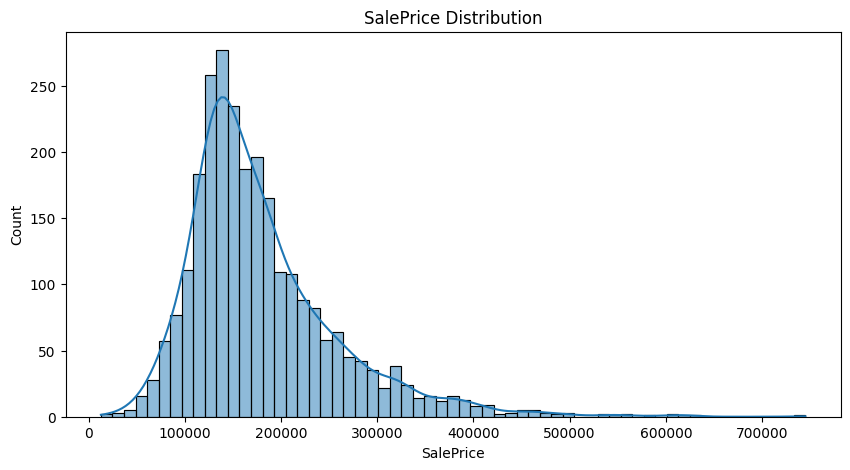

In [ ]:
import matplotlib.pyplot as plt  # ploting mean and median values of sale price in histogram, title, x label sale price, y is count
import seaborn as sns

'''
plt.figure(figsize = (10, 5))
plt.hist(housing['SalePrice'], bins=50, edgecolor='black')
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()
'''

plt.figure(figsize=(10, 5))
sns.histplot(housing['SalePrice'], kde=True)
plt.title('SalePrice Distribution')


print(f"Mean: {housing['SalePrice'].mean():.0f}")
print(f"Median: {housing['SalePrice'].median():0f}")

Plotly graph Histogram and Kernel Density Estimate most houses in the data are between 129,000 and 200 K with some expensive homes on the low part of the right part of the chart.

In [ ]:
import plotly.figure_factory as ff

# Wrap the single SalePrice series in an outer list - that's what the error message
# was hinting at: "make sure your hist_data variable is still a list of lists"
hist_data = [housing['SalePrice'].tolist()]
group_labels = ['SalePrice']
colors = ['#A56CC1']

fig = ff.create_distplot(hist_data, group_labels, colors=colors,
                         bin_size=10000, show_rug=False)
fig.update_layout(title_text='SalePrice Distribution (Histogram + KDE)')
fig.show()

Predictiors Qverall Quality shows somewhat of a normal distrubition, Gr Liv Area, Total Bsmt SF, and 1st Flr SF all show
positive skew and no garage and no basement indicate the na handling, distribution is not indictive of strong predictor on home values.

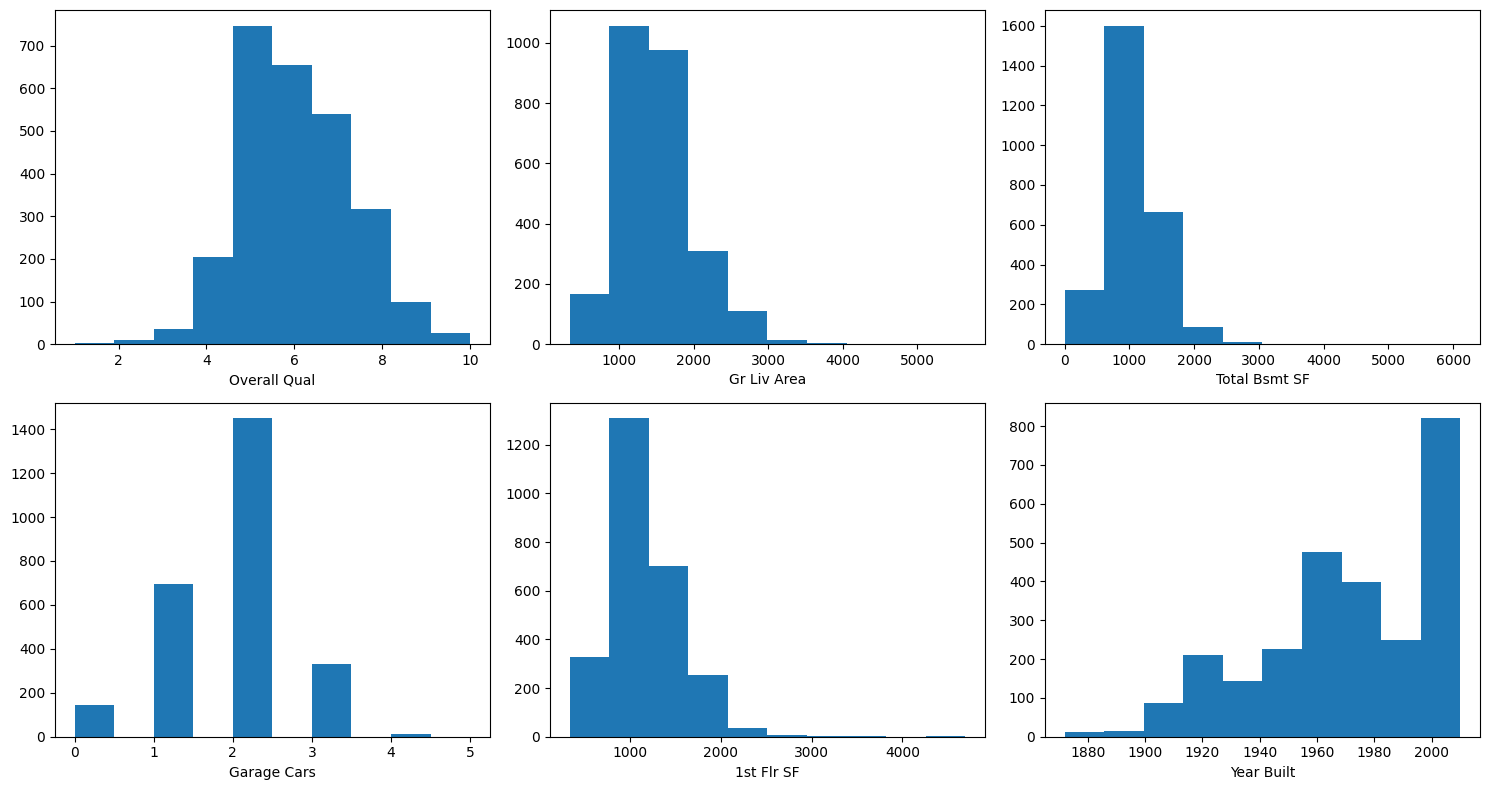

In [ ]:
key_cols = ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF',
            'Garage Cars', '1st Flr SF', 'Year Built']
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs_flat = axs.flatten()
for n, col in enumerate(key_cols):
    axs_flat[n].hist(housing[col].dropna())
    axs_flat[n].set_xlabel(col)
plt.tight_layout()


Correlations with SalesPrice will help us determine the strongest linear relationship to SalesPrice with features:  OveralQuality, Gr Living Area, Garage Cars at this point have higher values in the correlation.

In [ ]:
numeric_housing = housing.select_dtypes(include=['float64', 'int64'])

correlations = numeric_housing.corr()['SalePrice'].sort_values(ascending=False)
correlations.head(15)


,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.646874
Garage Area,0.633607
Total Bsmt SF,0.628955
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


Identify predictor pairs to drop in regularization. Looking for values between .80 and 1.0 - will change to .70 following this code block to see what other pairs output.

In [ ]:
corr_matrix = numeric_housing.corr().abs()

high_corr = corr_matrix.where(
    (corr_matrix > 0.8) & (corr_matrix < 1.0)
).stack().sort_values(ascending=False)
print(high_corr.head(20))


Garage Area    Garage Cars      0.892247
Garage Cars    Garage Area      0.892247
TotRms AbvGrd  Gr Liv Area      0.807065
Gr Liv Area    TotRms AbvGrd    0.807065
Overall Qual   SalePrice        0.805016
SalePrice      Overall Qual     0.805016
dtype: float64

In [ ]:
corr_matrix = numeric_housing.corr().abs()

high_corr = corr_matrix.where(
    (corr_matrix > 0.7) & (corr_matrix < 1.0)
).stack().sort_values(ascending=False)
print(high_corr.head(20))

Garage Cars    Garage Area      0.892247
Garage Area    Garage Cars      0.892247
Gr Liv Area    TotRms AbvGrd    0.807065
TotRms AbvGrd  Gr Liv Area      0.807065
SalePrice      Overall Qual     0.805016
Overall Qual   SalePrice        0.805016
Total Bsmt SF  1st Flr SF       0.782376
1st Flr SF     Total Bsmt SF    0.782376
Gr Liv Area    SalePrice        0.705482
SalePrice      Gr Liv Area      0.705482
dtype: float64

Checking SalePrice by neighborhood which may show that where you buy matters in house prices.

In [ ]:
housing.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

,SalePrice
Neighborhood,
NoRidge,323610.123077
StoneBr,319553.102041
NridgHt,318903.706667
GrnHill,280000.000000
Veenker,248314.583333
Timber,242343.967742
Somerst,230250.813665
Crawfor,211013.010526
ClearCr,209080.307692


# Processing the Data

Utilizing the data_dict to remove LabelEncoders alphabetizing, In this code block we are focusing on Ordinal data which is highlighted in the data_dict as yellow.  

In [ ]:
# Call every value that is ordinal
ordinal_cols = data_dict[data_dict['Type'] == 'Ordinal'][ 'Variable'].tolist()
print(f'{len(ordinal_cols)} ordinal columns to encode')
print(ordinal_cols)

# Changing quality ratings from str to 1 thru 5 scale: 1 being PO and 5 being EX. Zero means no rating
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
                'Heating QC', 'Kitchen Qual', 'Fireplace Qu',
                'Garage Qual', 'Garage Cond', 'Pool QC']
for col in quality_cols:
    housing[col] = housing[col].replace(quality_map)

# Other ordinal columns have their own specific scales - check the data dictionary
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
housing['Bsmt Exposure'] = housing['Bsmt Exposure'].replace(bsmt_exp_map)


23 ordinal columns to encode

[
    'Lot Shape',
    'Utilities',
    'Land Slope',
    'Overall Qual',
    'Overall Cond',
    'Exter Qual',
    'Exter Cond',
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Heating QC',
    'Electrical',
    'Kitchen Qual',
    'Functional',
    'Fireplace Qu',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Paved Drive',
    'Pool QC',
    'Fence'
]

/tmp/ipykernel_153407/2096185121.py:12: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_153407/2096185121.py:16: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Check if encoding worked


In [ ]:
# Step 10b — Remaining ordinal maps (Lot Shape, Utilities, Land Slope, etc.)
lot_shape_map     = {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}
utilities_map     = {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}
land_slope_map    = {'Gtl': 2, 'Mod': 1, 'Sev': 0}
bsmtfin_type_map  = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
electrical_map    = {'FuseP': 0, 'FuseF': 1, 'FuseA': 2, 'Mix': 3, 'SBrkr': 4}
functional_map    = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
paved_drive_map   = {'N': 0, 'P': 1, 'Y': 2}
fence_map         = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}

housing['Lot Shape']      = housing['Lot Shape'].replace(lot_shape_map).astype(int)
housing['Utilities']      = housing['Utilities'].replace(utilities_map).astype(int)
housing['Land Slope']     = housing['Land Slope'].replace(land_slope_map).astype(int)
housing['BsmtFin Type 1'] = housing['BsmtFin Type 1'].replace(bsmtfin_type_map).astype(int)
housing['BsmtFin Type 2'] = housing['BsmtFin Type 2'].replace(bsmtfin_type_map).astype(int)
housing['Electrical']     = housing['Electrical'].replace(electrical_map).astype(int)
housing['Functional']     = housing['Functional'].replace(functional_map).astype(int)
housing['Garage Finish']  = housing['Garage Finish'].replace(garage_finish_map).astype(int)
housing['Paved Drive']    = housing['Paved Drive'].replace(paved_drive_map).astype(int)
housing['Fence']          = housing['Fence'].replace(fence_map).astype(int)

# Verify
remaining_text = housing[['Lot Shape', 'Utilities', 'Land Slope', 'BsmtFin Type 1',
                          'BsmtFin Type 2', 'Electrical', 'Functional',
                          'Garage Finish', 'Paved Drive', 'Fence']].dtypes
print(remaining_text)

/tmp/ipykernel_153407/1883707722.py:12: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_153407/1883707722.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_153407/1883707722.py:14: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_153407/1883707722.py:15: Future

Lot Shape         int64
Utilities         int64
Land Slope        int64
BsmtFin Type 1    int64
BsmtFin Type 2    int64
Electrical        int64
Functional        int64
Garage Finish     int64
Paved Drive       int64
Fence             int64
dtype: object

In [ ]:
housing[['Exter Qual', 'Bsmt Qual', 'Kitchen Qual', 'Bsmt Exposure']].head(10)

,Exter Qual,Bsmt Qual,Kitchen Qual,Bsmt Exposure
0,3,3,3,1
1,3,0,3,0
2,3,3,4,1
3,4,4,4,1
4,4,4,4,1
5,3,3,3,1
6,4,4,4,3
7,3,4,3,2
8,4,4,4,1
9,3,3,4,2


Encoding nominal columns.  Column count increased below because the nominal encoding drops the column header and treats each unique value in that column as a new feature, this produces expansion in the dataset. We are trying to reduce collinearity in the data set, so drop_first = True to avoid collinearity.

pd.get_dummies is translating string features into binary numbers 1, 0 because the regression model is not capable of determining what 'Foundation' means, the ML is trained on numeric computation.   
Initial column value 81, this value 224.   





---



In [ ]:
# Get every nominal column from the data dictionary, except PID (it's just an ID)
nominal_cols = data_dict[data_dict['Type'] == 'Nominal']['Variable'].tolist()
nominal_cols = [c for c in nominal_cols if c != 'PID']
print(f"{len(nominal_cols)} nominal columns to one-hot encode:")
print(nominal_cols)

housing_encoded = pd.get_dummies(
    housing, columns=nominal_cols, drop_first=True, dtype=int
)
housing_encoded.shape


23 nominal columns to one-hot encode:

[
    'MS SubClass',
    'MS Zoning',
    'Street',
    'Alley',
    'Land Contour',
    'Lot Config',
    'Neighborhood',
    'Condition 1',
    'Condition 2',
    'Bldg Type',
    'House Style',
    'Roof Style',
    'Roof Matl',
    'Exterior 1st',
    'Exterior 2nd',
    'Mas Vnr Type',
    'Foundation',
    'Heating',
    'Central Air',
    'Garage Type',
    'Misc Feature',
    'Sale Type',
    'Sale Condition'
]

(2637, 224)

Feature separation X has all features for the model (2637, 222) and y is now a single dimensional series 'SalePrice' = (2637,).

In [ ]:
y = housing_encoded['SalePrice']
X = housing_encoded.drop(columns=['SalePrice', 'PID'])

print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (2637, 222), y shape: (2637,)

Structuring data for modeling import train_test_split.  Side note In Project 1 (classification — Naive Bayes), we used stratify=y to make sure each fold had the same proportion of each class, not necessary in regression model, the values for the y dimension must be continous values therefore random_state = 42 is used for the model, even boundaries are not needed.

Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(2109, 222)
(528, 222)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f"Train mean (should be ~0):   {X_train_scaled.mean():.6f}")
print(f"Train std  (should be ~1):   {X_train_scaled.std():.6f}")
print(f"Train shape: {X_train_scaled.shape}")

Train mean (should be ~0):   -0.000000

Train std  (should be ~1):   0.995485

Train shape: (2109, 222)

Modeling - Baseline Regression Root Mean Squared Error (RMSE) $25,267 and Root Mean Squared Percentage Error (RMSPE) 13.18%  without regularization. Our sales price is within 13% and we may see a better improvement in the prediction when using Lasso modeling with less features.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)

y_pred_baseline = baseline.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred_baseline) ** 0.5
rmspe = np.sqrt(np.mean(np.square((y_test - y_pred_baseline) / y_test))) * 100

print(f"Baseline RMSE:  {rmse:.0f}")
print(f"Baseline RMSPE: {rmspe:.2f}%")

Baseline RMSE:  25267

Baseline RMSPE: 13.18%

In [ ]:
print(baseline)

LinearRegression()

Cross Validation shows high variance between the baseline and cross validation RMSE which is $34,695 or 37% higher than the baseline.  We have a bimodal distribution in cross validation - some of the folds align with the baseline value and four of the folds exceed $46,000.  We are overfitting - a sign of instability in the model.  Will use Lasso for regularization.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    baseline, X_train_scaled, y_train,
    scoring='neg_root_mean_squared_error', cv=10
)
cv_rmse = abs(cv_scores.mean())
print(f"CV RMSE: {cv_rmse:.0f}")

CV RMSE: 34695

Dont truss the data

In [ ]:


print("Individual fold RMSEs:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {abs(score):.0f}")
print(f"\nMin: {abs(cv_scores).min():.0f}")
print(f"Max: {abs(cv_scores).max():.0f}")
print(f"Std: {cv_scores.std():.0f}")

Individual fold RMSEs:

Fold 1: 46817

Fold 2: 47762

Fold 3: 21171

Fold 4: 22559

...

Fold 9: 23198

Fold 10: 26547

Min: 21171

Max: 56815

Std: 14458

Lasso Regression and Feature Selection to reduce variance. Using Lasso to zero out weak coefficents.  We are looking for the best alpha which Lasso does in the model.  Baseline is really good but the model may require a manual alpha change.  Best alpha: 883.5005
Lasso RMSPE: 14.58%
Selected: 74 of 222 features
Dropped: 148 features

In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print(f"Best alpha: {lasso.alpha_:.4f}")

y_pred_lasso = lasso.predict(X_test_scaled)
rmspe_lasso = np.sqrt(np.mean(np.square((y_test - y_pred_lasso) / y_test))) * 100
print(f"Lasso RMSPE: {rmspe_lasso:.2f}%")

# Which features survived (nonzero coefficient)?
feature_names = X.columns
selected = feature_names[lasso.coef_ != 0]
dropped = feature_names[lasso.coef_ == 0]
print(f"Selected: {len(selected)} of {len(feature_names)} features")
print(f"Dropped: {len(dropped)} features")

Best alpha: 883.5005

Lasso RMSPE: 14.58%

Selected: 74 of 222 features

Dropped: 148 features

Comparing above Lasso output to the beleow output with changed ALPHA

In [ ]:
from sklearn.linear_model import Lasso

# Refit Lasso at the chosen alpha and cross-validate it the same way as baseline
lasso_fixed = Lasso(alpha=lasso.alpha_, max_iter=10000)
cv_scores_lasso = cross_val_score(
    lasso_fixed, X_train_scaled, y_train,
    scoring='neg_root_mean_squared_error', cv=10
)

print(f"Lasso CV RMSE: {abs(cv_scores_lasso.mean()):.0f}")
print(f"Lasso CV std:  {cv_scores_lasso.std():.0f}")
print()
print("Individual fold RMSEs:")
for i, score in enumerate(cv_scores_lasso):
    print(f"  Fold {i+1}: {abs(score):.0f}")
print(f"\nFor comparison:")
print(f"  Baseline CV RMSE: 34695, std: 14458")

Lasso CV RMSE: 27892

Lasso CV std:  7207

Individual fold RMSEs:

Fold 1: 25991

Fold 2: 46441

...

Fold 8: 33861

Fold 9: 25452

Fold 10: 23593

For comparison:

Baseline CV RMSE: 34695, std: 14458

**Lasso vs. Baseline — head-to-head comparison:**

| Metric | Baseline (222 features) | Lasso (74 features) |
|--------|------------------------|---------------------|
| Single-split RMSPE | 13.18% (lucky split) | 14.58% |
| CV RMSE | $34,695 | $27,892 |
| CV std (stability) | $14,458 | $7,207 |
| Features used | 222 | 74 (148 dropped) |

Lasso reduces CV RMSE by ~$6,800 and cuts fold-to-fold variance in half —
the bimodal blowout pattern from the baseline is mostly resolved, with only
Fold 2 still showing the old behavior. The single-split RMSPE looked
slightly worse for Lasso, but that's because the baseline's split happened
to be lucky; CV reveals Lasso is the more reliable model. Meets the
"minimum set of variables" goal: 148 features dropped, only 74 retained.

Refit on selected features

In [ ]:
# Pull just the surviving features, refit plain LinearRegression on them
selected_mask = lasso.coef_ != 0
X_train_selected = X_train_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]

final = LinearRegression()
final.fit(X_train_selected, y_train)
y_pred_final = final.predict(X_test_selected)

rmspe_final = np.sqrt(np.mean(np.square((y_test - y_pred_final) / y_test))) * 100
print(f"Final RMSPE (Lasso-selected, plain regression): {rmspe_final:.2f}%")

Final RMSPE (Lasso-selected, plain regression): 14.01%

Cross validating the refit shows better RMSE $27,408 and smaller variance std is $6,836 with a minimum set o variables - Lasso refit selected 74 features to give us these values.  Better performance than the Baseline and Lasso 1 and Lasso 2.

In [ ]:
from sklearn.model_selection import cross_val_score

final_for_cv = LinearRegression()
cv_scores_final = cross_val_score(
    final_for_cv, X_train_selected, y_train,
    scoring='neg_root_mean_squared_error', cv=10
)
print(f"Refit CV RMSE: {abs(cv_scores_final.mean()):.0f}")
print(f"Refit CV std:  {cv_scores_final.std():.0f}")
print()
print("For comparison:")
print(f"  Baseline CV RMSE:   34695, std: 14458")
print(f"  Lasso CV RMSE:      27892, std: 7207")

Refit CV RMSE: 27408

Refit CV std:  6836

For comparison:

Baseline CV RMSE:   34695, std: 14458

Lasso CV RMSE:      27892, std: 7207

Predicted versus actual plot

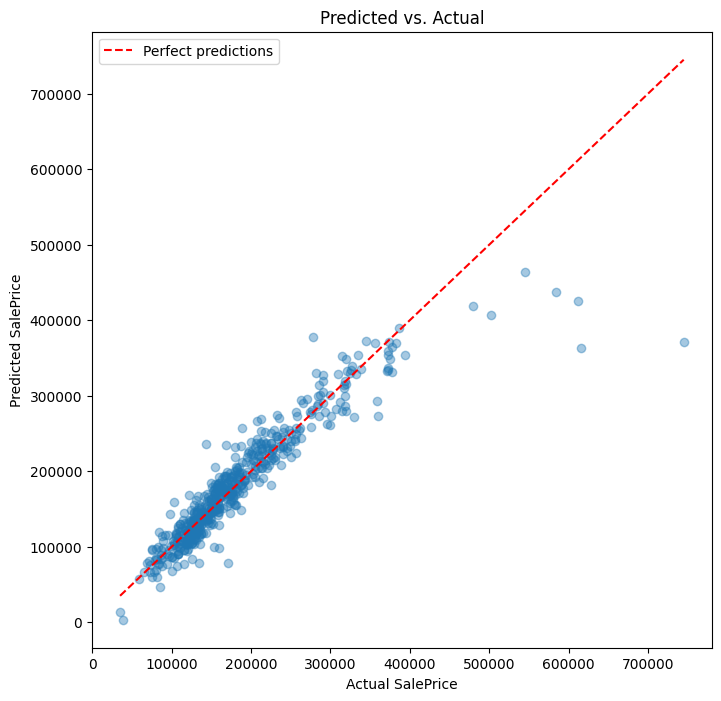

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_final, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect predictions')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.legend()
plt.title('Predicted vs. Actual')
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Build a small DataFrame for plotly
results = pd.DataFrame({
    'Actual SalePrice': y_test.values,
    'Predicted SalePrice': y_pred_final
})

fig = px.scatter(
    results,
    x='Actual SalePrice',
    y='Predicted SalePrice',
    opacity=0.5,
    title='Predicted vs. Actual SalePrice — Final Model (Lasso-selected, 74 features)',
)

# Add the "perfect prediction" diagonal line
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    name='Perfect predictions',
    line=dict(color='red', dash='dash')
))

fig.update_layout(
    width=800, height=800,
    xaxis_title='Actual SalePrice ($)',
    yaxis_title='Predicted SalePrice ($)',
)
fig.show()

Residuals vs. Fitted:

QQ plot: most home values follow the normal distribution, but expensive homes cause the distribution to move off the reference line

Homes with low value and up to $200k follow the reference line and keep low variance in the model.  This changes with home higher home values.

Homes beyond $300K predicted prices start to see wider variance beyond that value. A log transformation can help with this regression model since the values in the data set are positively skewed.




# Data Visualization/Communication of Results

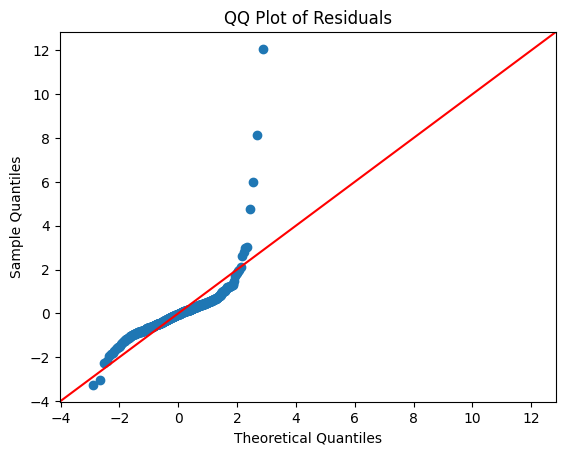

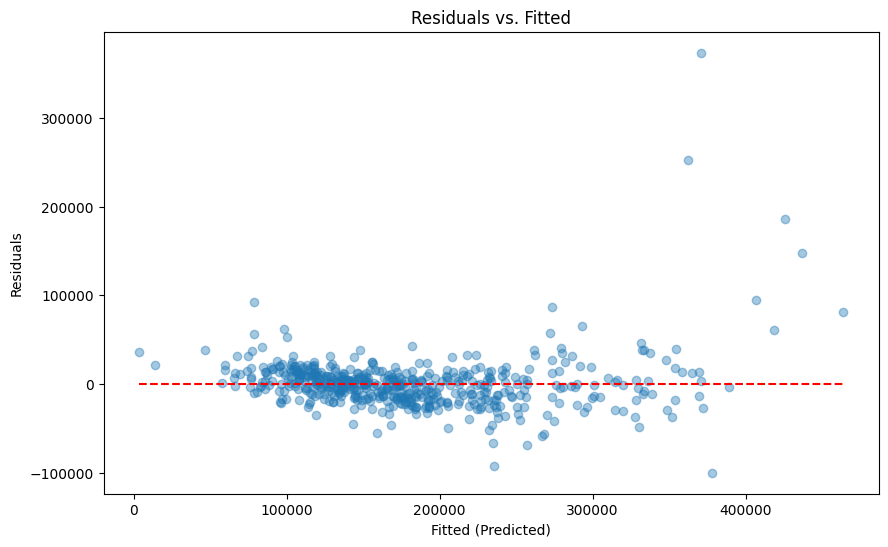

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

residuals = y_test - y_pred_final

# QQ plot — are residuals approximately normal?
sm.qqplot(residuals, fit=True, line='45')
plt.title('QQ Plot of Residuals')
plt.show()

# Residuals vs. fitted — is variance constant?
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_final, residuals, alpha=0.4)
plt.hlines(0, y_pred_final.min(), y_pred_final.max(), colors='red', linestyles='dashed')
plt.xlabel('Fitted (Predicted)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted')
plt.show()

Summary comparison table
Refit Lasso performed better than baseline and initial Lasso.

In [ ]:
summary = pd.DataFrame({
    'Model': ['Baseline (all features)', 'Lasso (shrunken)', 'Refit (final)'],
    'Features': [222, 74, 74],
    'Test RMSPE (%)': [13.18, 14.58, 14.01],
    'CV RMSE ($)': [34695, 27892, 27408],
    'CV std ($)': [14458, 7207, 6836],
})
summary

,Model,Features,Test RMSPE (%),CV RMSE ($),CV std ($)
0,Baseline (all features),222,13.18,34695,14458
1,Lasso (shrunken),74,14.58,27892,7207
2,Refit (final),74,14.01,27408,6836


Top Feature Coefficients are 15 with GR Liv Area at the very top, these features are the most important in predicting sale price.  

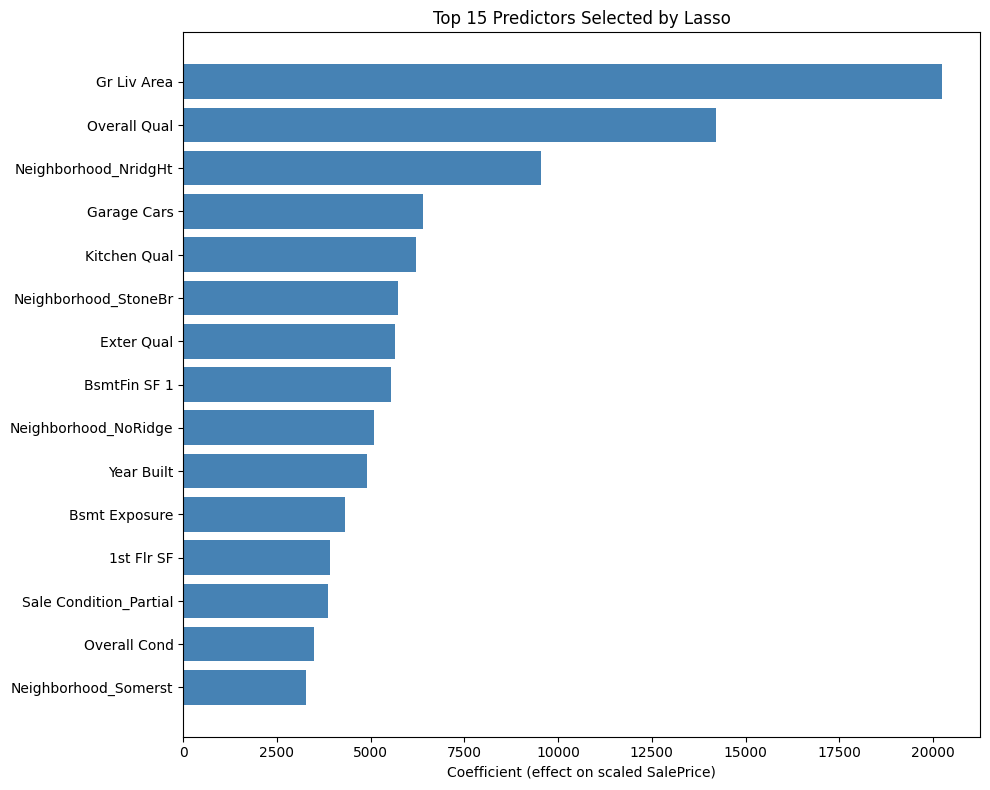

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns[lasso.coef_ != 0],
    'Coefficient': lasso.coef_[lasso.coef_ != 0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient (effect on scaled SalePrice)')
plt.title('Top 15 Predictors Selected by Lasso')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Summary:
Utilized regression modeling to predict what features increased sale price. The top 15 features were predicted through the regression model, with an initial bias in our second round of Lasso.  This bias selected for features that were not strong coefficients, despite Lasso use of reducing weak features it also tends to push stronger features toward the zero or the mean.  Despite reducing variance, it is not accurate and refitting is necessary to improve the models *bias variance trade off*

Three-model comparison:

| Model | Features | Test RMSPE | CV RMSE | CV std |
|---|---|---|---|---|
| Baseline | 222 | 13.18% | $34,695 | $14,458 |
| Lasso (shrunken) | 74 | 14.58% | $27,892 | $7,207 |
| **Refit (final)** | **74** | **14.01%** | **$27,408** | **$6,836** |

